In [1]:
!pip install rasterio cartopy pyproj tqdm imageio

In [2]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.path as mpath

from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [3]:
# ==========================================================
# PROJECT PATHS
# ==========================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

DATA = os.path.join(PROJECT, "Data")

OUTPUT = os.path.join(PROJECT, "OUTPUT")

POLAR_OUTPUT = os.path.join(
    OUTPUT,
    "Publication_Maps"
)

os.makedirs(POLAR_OUTPUT, exist_ok=True)

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

print("="*50)
print("PROJECT PATHS")
print("="*50)

print("Project :", PROJECT)
print("Data    :", DATA)
print("Output  :", POLAR_OUTPUT)

PROJECT PATHS
Project : C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2
Data    : C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Data
Output  : C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Publication_Maps


In [4]:
# ==========================================================
# LOAD LATITUDE MASK
# ==========================================================

latitude_mask = np.load(
    os.path.join(PROJECT, "latitude_mask.npy")
)

print("="*50)
print("LATITUDE MASK")
print("="*50)

print("Shape :", latitude_mask.shape)
print()

print("Pixels Above 60°N :",
      np.sum(latitude_mask))

LATITUDE MASK
Shape : (448, 304)

Pixels Above 60°N : 55512


In [5]:
# ==========================================================
# NSIDC COLOR MAP
# ==========================================================

cmap = ListedColormap(

[
    "#5DADE2",     # Ocean

    "#FFFFFF",     # Sea Ice

    "#CFCFCF"      # Land

]

)

norm = BoundaryNorm(

[-0.5,0.5,1.5,2.5],

cmap.N

)

print("Color Map Created.")

Color Map Created.


In [6]:
# # ==========================================================
# # PLOT ONE POLAR MAP
# # ==========================================================

# def plot_seaice_map(image_path, save_path, title):

#     with rasterio.open(image_path) as src:

#         raster = src.read(1)

#         bounds = src.bounds

#     # ------------------------------------------------------
#     # Apply Latitude Mask
#     # ------------------------------------------------------

#     raster = np.where(latitude_mask, raster, 253)

#     # ------------------------------------------------------
#     # Convert Raster Classes
#     # ------------------------------------------------------

#     plot_data = np.full(raster.shape, np.nan)

#     # Ocean
#     plot_data[raster == 0] = 0

#     # Sea Ice
#     plot_data[raster == 1] = 1

#     # Land
#     plot_data[raster == 254] = 2

#     # ------------------------------------------------------
#     # Create Figure
#     # ------------------------------------------------------

#     fig = plt.figure(figsize=(9,9))

#     ax = plt.axes(
#         projection=ccrs.NorthPolarStereo()
#     )

#     ax.set_extent(
#         [-180,180,60,90],
#         ccrs.PlateCarree()
#     )

#     # ------------------------------------------------------
#     # Circular Boundary
#     # ------------------------------------------------------

#     theta = np.linspace(0,2*np.pi,200)

#     center = np.array([0.5,0.5])

#     radius = 0.5

#     verts = np.vstack(
#         [np.sin(theta),np.cos(theta)]
#     ).T

#     circle = mpath.Path(
#         verts*radius + center
#     )

#     ax.set_boundary(
#         circle,
#         transform=ax.transAxes
#     )

#     # ------------------------------------------------------
#     # Plot Raster
#     # ------------------------------------------------------

#     ax.imshow(

#         plot_data,

#         origin="upper",

#         extent=[
#             bounds.left,
#             bounds.right,
#             bounds.bottom,
#             bounds.top
#         ],

#         transform=ccrs.epsg(3411),

#         cmap=cmap,

#         norm=norm,

#         interpolation="nearest",

#         zorder=2

#     )

#     # ------------------------------------------------------
#     # Coastlines
#     # ------------------------------------------------------

#     ax.coastlines(
#         resolution="10m",
#         linewidth=0.6,
#         color="black"
#     )

#     # ------------------------------------------------------
#     # Gridlines
#     # ------------------------------------------------------

#     ax.gridlines(

#         linewidth=0.5,

#         color="gray",

#         alpha=0.5,

#         linestyle="--"

#     )

#     # ------------------------------------------------------
#     # Title
#     # ------------------------------------------------------

#     plt.title(
#         title,
#         fontsize=18,
#         fontweight="bold",
#         pad=20
#     )

#     # ------------------------------------------------------
#     # Save
#     # ------------------------------------------------------

#     plt.savefig(

#         save_path,

#         dpi=600,

#         bbox_inches="tight"

#     )

#     plt.close()

In [7]:
# ==========================================================
# PUBLICATION QUALITY POLAR MAP FUNCTION
# ==========================================================

def plot_seaice_map(image_path, save_path, title):

    with rasterio.open(image_path) as src:

        raster = src.read(1)
        bounds = src.bounds

    # ------------------------------------------------------
    # Apply 60°N Latitude Mask
    # ------------------------------------------------------

    raster = np.where(latitude_mask, raster, 253)

    # ------------------------------------------------------
    # Convert Raster Classes
    # ------------------------------------------------------

    plot_data = np.full(raster.shape, np.nan)

    # Ocean
    plot_data[raster == 0] = 0

    # Sea Ice
    plot_data[raster == 1] = 1

    # Land
    plot_data[raster == 254] = 2

    # ------------------------------------------------------
    # Professional Color Map
    # ------------------------------------------------------

    cmap = ListedColormap([
        "#2C5AA0",   # Ocean (Dark Blue)
        "#FFFFFF",   # Sea Ice (White)
        "#9A9A9A"    # Land (Gray)
    ])

    norm = BoundaryNorm(
        [-0.5, 0.5, 1.5, 2.5],
        cmap.N
    )

    # ------------------------------------------------------
    # Figure
    # ------------------------------------------------------

    fig = plt.figure(figsize=(10,10))

    ax = plt.axes(
        projection=ccrs.NorthPolarStereo()
    )

    ax.set_extent(
        [-180,180,60,90],
        crs=ccrs.PlateCarree()
    )

    # ------------------------------------------------------
    # Circular Boundary
    # ------------------------------------------------------

    theta = np.linspace(0,2*np.pi,400)

    center = np.array([0.5,0.5])

    radius = 0.5

    verts = np.vstack(
        [np.sin(theta),np.cos(theta)]
    ).T

    circle = mpath.Path(
        verts*radius + center
    )

    ax.set_boundary(
        circle,
        transform=ax.transAxes
    )

    # ------------------------------------------------------
    # Plot Raster
    # ------------------------------------------------------

    ax.imshow(

        plot_data,

        origin="upper",

        extent=[
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ],

        transform=ccrs.epsg(3411),

        cmap=cmap,

        norm=norm,

        interpolation="nearest",

        zorder=1

    )

    # ------------------------------------------------------
    # Coastlines
    # ------------------------------------------------------

    ax.coastlines(

        resolution="10m",

        linewidth=0.8,

        color="black",

        zorder=5

    )

    # ------------------------------------------------------
    # Gridlines
    # ------------------------------------------------------

    gl = ax.gridlines(

        draw_labels=False,

        linewidth=0.7,

        color="gray",

        alpha=0.7,

        linestyle="--"

    )

    # ------------------------------------------------------
    # Title
    # ------------------------------------------------------

    plt.title(

        title,

        fontsize=17,

        fontweight="bold",

        pad=18

    )

    # ------------------------------------------------------
    # Save Figure
    # ------------------------------------------------------

    plt.savefig(

        save_path,

        dpi=600,

        bbox_inches="tight",

        pad_inches=0.02

    )

    plt.close()

In [8]:
image = os.path.join(
    DATA,
    "March",
    "N_200003_extent_v4.0.tif"
)

save = os.path.join(
    POLAR_OUTPUT,
    "March_2000.png"
)

plot_seaice_map(
    image,
    save,
    "Arctic Sea Ice Extent\nMarch 2000 (60°N–90°N)"
)

C:\Users\ACER\AppData\Local\Temp\ipykernel_2652\3998216893.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raster = src.read(1)


# Generate all 182 Polar Maps

In [9]:
# ==========================================================
# GENERATE ALL PUBLICATION QUALITY POLAR MAPS
# ==========================================================

import glob

# Output Folder
POLAR_OUTPUT = os.path.join(OUTPUT, "Publication_Maps")
os.makedirs(POLAR_OUTPUT, exist_ok=True)

total_maps = 0

print("="*60)
print("GENERATING PUBLICATION QUALITY POLAR MAPS")
print("="*60)

for month in months:

    print(f"\nProcessing {month}...")

    month_input = os.path.join(DATA, month)
    month_output = os.path.join(POLAR_OUTPUT, month)

    os.makedirs(month_output, exist_ok=True)

    tif_files = sorted(glob.glob(os.path.join(month_input, "*.tif")))

    for tif in tif_files:

        filename = os.path.basename(tif)

        # Extract Year (N_200003_extent_v4.0.tif -> 2000)
        year = filename[2:6]

        save_name = f"{month}_{year}.png"

        save_path = os.path.join(
            month_output,
            save_name
        )

        title = f"Arctic Sea Ice Extent\n{month} {year} (60°N–90°N)"

        plot_seaice_map(
            tif,
            save_path,
            title
        )

        total_maps += 1

        print(f"{total_maps:03d}  {save_name}")

print("\n" + "="*60)
print("COMPLETED")
print("="*60)
print(f"Total Maps Created : {total_maps}")
print(f"Saved To : {POLAR_OUTPUT}")

GENERATING PUBLICATION QUALITY POLAR MAPS

Processing March...


C:\Users\ACER\AppData\Local\Temp\ipykernel_2652\3998216893.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raster = src.read(1)


001  March_2000.png


C:\Users\ACER\AppData\Local\Temp\ipykernel_2652\3998216893.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raster = src.read(1)


002  March_2001.png


...

184  September_2023.png


C:\Users\ACER\AppData\Local\Temp\ipykernel_2652\3998216893.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raster = src.read(1)


185  September_2024.png


C:\Users\ACER\AppData\Local\Temp\ipykernel_2652\3998216893.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raster = src.read(1)


186  September_2025.png

COMPLETED
Total Maps Created : 186
Saved To : C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Publication_Maps


In [10]:
# ==========================================================
# CREATE ONE MP4 (ALL 182 MAPS)
# ==========================================================

import os
import cv2

VIDEO_OUTPUT = os.path.join(OUTPUT, "Videos")
os.makedirs(VIDEO_OUTPUT, exist_ok=True)

all_images = []

print("="*60)
print("Collecting Images...")
print("="*60)

for year in range(2000, 2026):

    for month in months:

        image = os.path.join(
            POLAR_OUTPUT,
            month,
            f"{month}_{year}.png"
        )

        if os.path.exists(image):
            all_images.append(image)

print(f"Total Images : {len(all_images)}")

# ----------------------------------------------------------
# Read First Image
# ----------------------------------------------------------

first = cv2.imread(all_images[0])

height, width, _ = first.shape

video_path = os.path.join(
    VIDEO_OUTPUT,
    "Arctic_Sea_Ice_2000_2025.mp4"
)

# ----------------------------------------------------------
# Video Writer
# ----------------------------------------------------------

fps = 2

writer = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

print("\nCreating Video...\n")

for i, image in enumerate(all_images):

    frame = cv2.imread(image)

    writer.write(frame)

    print(f"{i+1:03d}/{len(all_images)}")

writer.release()

print("\n" + "="*60)
print("VIDEO CREATED SUCCESSFULLY")
print("="*60)
print(video_path)

Total Images : 182

Creating Video...

001/182
002/182
003/182
004/182
005/182
006/182
007/182
008/182
009/182
010/182
011/182
012/182
013/182
014/182
015/182
016/182
017/182
018/182
019/182
020/182
021/182
022/182
023/182
024/182
025/182
026/182
027/182
028/182
029/182
030/182
031/182
032/182
033/182
034/182
035/182
036/182
037/182
038/182
039/182
040/182
041/182
042/182
043/182
044/182
045/182
046/182
047/182
048/182
049/182
050/182
051/182
052/182
053/182
054/182
055/182
056/182
057/182
058/182
059/182
060/182
061/182
062/182
063/182
064/182
065/182
066/182
067/182
068/182
069/182
070/182
071/182
072/182
073/182
074/182
075/182
076/182
077/182
078/182
079/182
080/182
081/182
082/182
083/182
084/182
085/182
086/182
087/182
088/182
089/182
090/182
091/182
092/182
093/182
094/182
095/182
096/182
097/182
098/182
099/182
100/182
101/182
102/182
103/182
104/182
105/182
106/182
107/182
108/182
109/182
110/182
111/182
112/182
113/182
114/182
115/182
116/182
117/182
118/182
119/182
120/182
1

In [11]:
# ==========================================================
# CREATE GIFS
# ==========================================================

import os
import imageio.v2 as imageio

GIF_OUTPUT = os.path.join(OUTPUT, "GIFs")
os.makedirs(GIF_OUTPUT, exist_ok=True)

folders = {
    "Mean_Sea_Ice": "_Mean.png",
    "Persistent_Sea_Ice": "_Persistent.png"
}

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

print("=" * 60)
print("CREATING GIFS")
print("=" * 60)

for folder, suffix in folders.items():

    frames = []

    print(f"\nProcessing {folder}...")

    for month in months:

        image_path = os.path.join(
            OUTPUT,
            folder,
            f"{month}{suffix}"
        )

        if os.path.exists(image_path):

            frames.append(imageio.imread(image_path))
            print(f"Added : {os.path.basename(image_path)}")

        else:

            print(f"Missing : {os.path.basename(image_path)}")

    if len(frames) == 0:

        print(f"\nNo images found for {folder}. GIF skipped.")
        continue

    gif_path = os.path.join(
        GIF_OUTPUT,
        f"{folder}.gif"
    )

    imageio.mimsave(
        gif_path,
        frames,
        duration=7.0,
        loop=0
    )

    print(f"\nSaved : {gif_path}")

print("\n" + "=" * 60)
print("ALL GIFS CREATED SUCCESSFULLY")
print("=" * 60)

CREATING GIFS

Processing Mean_Sea_Ice...
Added : March_Mean.png
Added : April_Mean.png
Added : May_Mean.png
Added : June_Mean.png
Added : July_Mean.png
Added : August_Mean.png
Added : September_Mean.png

Saved : C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\GIFs\Mean_Sea_Ice.gif

Processing Persistent_Sea_Ice...
Missing : March_Persistent.png
Missing : April_Persistent.png
Missing : May_Persistent.png
Missing : June_Persistent.png
Missing : July_Persistent.png
Missing : August_Persistent.png
Missing : September_Persistent.png

No images found for Persistent_Sea_Ice. GIF skipped.

ALL GIFS CREATED SUCCESSFULLY


In [12]:
# ==========================================================
# CREATE MP4 FOR MEAN SEA ICE ONLY
# ==========================================================

import os
import imageio.v2 as imageio

# Output folder containing the Mean_Sea_Ice images
MEAN_FOLDER = os.path.join(OUTPUT, "Mean_Sea_Ice")

# Folder where the MP4 will be saved
VIDEO_OUTPUT = os.path.join(OUTPUT, "Videos")
os.makedirs(VIDEO_OUTPUT, exist_ok=True)

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

frames = []

print("=" * 60)
print("CREATING MEAN SEA ICE MP4")
print("=" * 60)

for month in months:

    image_path = os.path.join(
        MEAN_FOLDER,
        f"{month}_Mean.png"
    )

    if os.path.exists(image_path):

        frames.append(imageio.imread(image_path))
        print(f"Added : {month}_Mean.png")

    else:

        print(f"Missing : {month}_Mean.png")

if len(frames) == 0:

    print("\nNo images found. MP4 not created.")

else:

    video_path = os.path.join(
        VIDEO_OUTPUT,
        "Mean_Sea_Ice.mp4"
    )

    # FPS controls speed:
    # 1.0  = 1 second per image
    # 0.5  = 2 seconds per image
    # 0.25 = 4 seconds per image (very slow)

    imageio.mimsave(
        video_path,
        frames,
        fps=0.5
    )

    print("\nSaved Successfully!")
    print(video_path)

print("=" * 60)

CREATING MEAN SEA ICE MP4
Added : March_Mean.png
Added : April_Mean.png
Added : May_Mean.png
Added : June_Mean.png
Added : July_Mean.png
Added : August_Mean.png
Added : September_Mean.png


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1679, 2012) to (1680, 2016) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).



Saved Successfully!
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Videos\Mean_Sea_Ice.mp4


In [13]:
!pip install imageio[ffmpeg]

In [14]:
# ==========================================================
# CREATE MP4 FOR PERSISTENT SEA ICE ONLY
# ==========================================================

import os
import cv2

PERSISTENT_FOLDER = os.path.join(OUTPUT, "Persistent_Sea_Ice")

VIDEO_OUTPUT = os.path.join(OUTPUT, "Videos")
os.makedirs(VIDEO_OUTPUT, exist_ok=True)

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

images = []

print("=" * 60)
print("CREATING PERSISTENT SEA ICE MP4")
print("=" * 60)

for month in months:

    image_path = os.path.join(
        PERSISTENT_FOLDER,
        f"{month}_Persistence.png"
    )

    if os.path.exists(image_path):

        img = cv2.imread(image_path)

        images.append(img)

        print(f"Added : {month}_Persistence.png")

    else:

        print(f"Missing : {month}_Persistence.png")

if len(images) == 0:

    raise Exception("No images found!")

height, width, _ = images[0].shape

video_path = os.path.join(
    VIDEO_OUTPUT,
    "Persistent_Sea_Ice.mp4"
)

# MP4 Codec
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# fps = 0.5 means each image stays for about 2 seconds
video = cv2.VideoWriter(
    video_path,
    fourcc,
    0.5,
    (width, height)
)

for img in images:

    video.write(img)

video.release()

print("\n" + "=" * 60)
print("VIDEO CREATED SUCCESSFULLY")
print("=" * 60)
print("Saved at:")
print(video_path)

CREATING PERSISTENT SEA ICE MP4
Added : March_Persistence.png
Added : April_Persistence.png
Added : May_Persistence.png
Added : June_Persistence.png
Added : July_Persistence.png
Added : August_Persistence.png
Added : September_Persistence.png

VIDEO CREATED SUCCESSFULLY
Saved at:
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Videos\Persistent_Sea_Ice.mp4


In [15]:
# ==========================================================
# YEARLY MEAN OUTPUT
# ==========================================================

YEARLY_OUTPUT = os.path.join(
    OUTPUT,
    "Yearly_Mean_Maps"
)

os.makedirs(YEARLY_OUTPUT, exist_ok=True)

print("="*60)
print("Yearly Output Folder")
print("="*60)
print(YEARLY_OUTPUT)

Yearly Output Folder
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Yearly_Mean_Maps


In [16]:
month_number = {
    "March": "03",
    "April": "04",
    "May": "05",
    "June": "06",
    "July": "07",
    "August": "08",
    "September": "09"
}

In [17]:
# ==========================================================
# CREATE YEARLY BINARY SEA ICE MAPS
# ==========================================================

years = range(2000, 2026)

for year in years:

    print(f"\nProcessing {year}")

    monthly_binary = []

    land_mask = None

    # ---------------------------------------------
    # Read all 7 months
    # ---------------------------------------------

    for month in months:

        image_path = os.path.join(
            DATA,
            month,
            f"N_{year}{month_number[month]}_extent_v4.0.tif"
        )

        with rasterio.open(image_path) as src:

            raster = src.read(1)

        # Apply Latitude Mask
        raster = np.where(latitude_mask, raster, 253)

        # Save land mask only once
        if land_mask is None:
            land_mask = (raster == 254)

        # Binary sea ice
        ice = (raster == 1).astype(np.float32)

        monthly_binary.append(ice)

    # ---------------------------------------------
    # Mean of 7 Months
    # ---------------------------------------------

    yearly_mean = np.mean(monthly_binary, axis=0)

    # ---------------------------------------------
    # Threshold
    # ---------------------------------------------

    yearly_binary = np.where(yearly_mean >= 0.5, 1, 0).astype(np.uint8)

    # Restore Land
    yearly_binary[land_mask] = 254

    # ---------------------------------------------
    # Save temporary array
    # ---------------------------------------------

    np.save(
        os.path.join(
            YEARLY_OUTPUT,
            f"Year_{year}.npy"
        ),
        yearly_binary
    )

    print(f"Saved Year {year}")

print("\nDone!")


Processing 2000
Saved Year 2000

Processing 2001
Saved Year 2001

Processing 2002


C:\Users\ACER\AppData\Local\Temp\ipykernel_2652\2608283905.py:29: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raster = src.read(1)


Saved Year 2002

Processing 2003
Saved Year 2003

Processing 2004
Saved Year 2004

Processing 2005
Saved Year 2005

Processing 2006
Saved Year 2006

Processing 2007
Saved Year 2007

Processing 2008
Saved Year 2008

Processing 2009
Saved Year 2009

Processing 2010
Saved Year 2010

Processing 2011
Saved Year 2011

Processing 2012
Saved Year 2012

Processing 2013
Saved Year 2013

Processing 2014
Saved Year 2014

Processing 2015
Saved Year 2015

Processing 2016
Saved Year 2016

Processing 2017
Saved Year 2017

Processing 2018
Saved Year 2018

Processing 2019
Saved Year 2019

Processing 2020
Saved Year 2020

Processing 2021
Saved Year 2021

Processing 2022
Saved Year 2022

Processing 2023
Saved Year 2023

Processing 2024
Saved Year 2024

Processing 2025
Saved Year 2025

Done!


In [18]:
# ==========================================================
# CREATE MP4 FROM YEARLY MAPS
# ==========================================================

import os
import cv2

YEARLY_FOLDER = os.path.join(
    OUTPUT,
    "Yearly_Mean_Maps"
)

VIDEO_FOLDER = os.path.join(
    OUTPUT,
    "Videos"
)

os.makedirs(VIDEO_FOLDER, exist_ok=True)

# ----------------------------------------------------------
# Collect Images
# ----------------------------------------------------------

images = []

for year in range(2000, 2026):

    img = os.path.join(
        YEARLY_FOLDER,
        f"Year_{year}.png"
    )

    if os.path.exists(img):
        images.append(img)

print("="*60)
print("YEARLY VIDEO")
print("="*60)
print(f"Frames Found : {len(images)}")

# ----------------------------------------------------------
# Read First Image
# ----------------------------------------------------------

frame = cv2.imread(images[0])

height, width, _ = frame.shape

# ----------------------------------------------------------
# Video Writer
# ----------------------------------------------------------

video_path = os.path.join(
    VIDEO_FOLDER,
    "Yearly_Sea_Ice_2000_2025.mp4"
)

fps = 1.5      # Recommended

writer = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

print("\nCreating Video...\n")

# ----------------------------------------------------------
# Write Frames
# ----------------------------------------------------------

for i, img in enumerate(images):

    frame = cv2.imread(img)

    writer.write(frame)

    year = 2000 + i

    print(f"Added : {year}")

writer.release()

print("\n" + "="*60)
print("VIDEO CREATED SUCCESSFULLY")
print("="*60)
print(video_path)

YEARLY VIDEO
Frames Found : 0


IndexError: list index out of range

In [ ]:
print(YEARLY_FOLDER)

C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Yearly_Mean_Maps


In [ ]:
import os

print(os.listdir(YEARLY_FOLDER))

['Year_2000.npy', 'Year_2001.npy', 'Year_2002.npy', 'Year_2003.npy', 'Year_2004.npy', 'Year_2005.npy', 'Year_2006.npy', 'Year_2007.npy', 'Year_2008.npy', 'Year_2009.npy', 'Year_2010.npy', 'Year_2011.npy', 'Year_2012.npy', 'Year_2013.npy', 'Year_2014.npy', 'Year_2015.npy', 'Year_2016.npy', 'Year_2017.npy', 'Year_2018.npy', 'Year_2019.npy', 'Year_2020.npy', 'Year_2021.npy', 'Year_2022.npy', 'Year_2023.npy', 'Year_2024.npy', 'Year_2025.npy']


In [ ]:
import rasterio
import os

sample = os.path.join(DATA, "March", "N_200003_extent_v4.0.tif")

with rasterio.open(sample) as src:
    print(src.bounds)

BoundingBox(left=-3850000.0, bottom=-5350000.0, right=3750000.0, top=5850000.0)


In [ ]:
# ==========================================================
# PLOT YEARLY MAP FROM NUMPY ARRAY
# ==========================================================

def plot_yearly_map(yearly_array, save_path, title):

    plot_data = np.full(yearly_array.shape, np.nan)

    # Ocean
    plot_data[yearly_array == 0] = 0

    # Sea Ice
    plot_data[yearly_array == 1] = 1

    # Land
    plot_data[yearly_array == 254] = 2

    cmap = ListedColormap([
        "#2C5AA0",
        "#FFFFFF",
        "#9A9A9A"
    ])

    norm = BoundaryNorm(
        [-0.5,0.5,1.5,2.5],
        cmap.N
    )

    fig = plt.figure(figsize=(10,10))

    ax = plt.axes(
        projection=ccrs.NorthPolarStereo()
    )

    ax.set_extent(
        [-180,180,60,90],
        crs=ccrs.PlateCarree()
    )

    # Circular Boundary
    theta = np.linspace(0,2*np.pi,400)

    center = np.array([0.5,0.5])

    radius = 0.5

    verts = np.vstack(
        [np.sin(theta),np.cos(theta)]
    ).T

    circle = mpath.Path(
        verts*radius + center
    )

    ax.set_boundary(
        circle,
        transform=ax.transAxes
    )

    # Plot
    ax.imshow(

        plot_data,

        origin="upper",

        extent=[
            -3850000,
            3750000,
            -5350000,
            5850000
        ],

        transform=ccrs.epsg(3411),

        cmap=cmap,

        norm=norm,

        interpolation="nearest"

    )

    ax.coastlines(
        resolution="10m",
        linewidth=0.8,
        color="black"
    )

    ax.gridlines(
        linewidth=0.7,
        linestyle="--",
        alpha=0.6
    )

    plt.title(
        title,
        fontsize=17,
        fontweight="bold"
    )

    plt.savefig(
        save_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.close()

In [ ]:
# ==========================================================
# CREATE YEARLY STEREOGRAPHIC MAPS
# ==========================================================

YEARLY_PNG = os.path.join(
    OUTPUT,
    "Yearly_Mean_PNG"
)

os.makedirs(YEARLY_PNG, exist_ok=True)

print("="*60)
print("CREATING YEARLY MAPS")
print("="*60)

for year in range(2000,2026):

    arr = np.load(

        os.path.join(
            YEARLY_OUTPUT,
            f"Year_{year}.npy"
        )

    )

    save = os.path.join(
        YEARLY_PNG,
        f"Year_{year}.png"
    )

    plot_yearly_map(

        arr,

        save,

        f"Yearly Mean Arctic Sea Ice\n{year}"

    )

    print(f"{year} Saved")

print("\nDone.")

CREATING YEARLY MAPS
2000 Saved
2001 Saved
2002 Saved
2003 Saved
2004 Saved
2005 Saved
2006 Saved
2007 Saved
2008 Saved
2009 Saved
2010 Saved
2011 Saved
2012 Saved
2013 Saved
2014 Saved
2015 Saved
2016 Saved
2017 Saved
2018 Saved
2019 Saved
2020 Saved
2021 Saved
2022 Saved
2023 Saved
2024 Saved
2025 Saved

Done.


In [ ]:
# ==========================================================
# YEARLY PNG OUTPUT FOLDER
# ==========================================================

YEARLY_PNG = os.path.join(
    OUTPUT,
    "Yearly_Mean_PNG"
)

os.makedirs(YEARLY_PNG, exist_ok=True)

print("Output Folder :", YEARLY_PNG)

Output Folder : C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Yearly_Mean_PNG


In [ ]:
# ==========================================================
# PLOT YEARLY STEREOGRAPHIC MAP
# ==========================================================

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.path as mpath

def plot_yearly_map(yearly_array, save_path, year):

    # ------------------------------------------------------
    # Convert classes for plotting
    # ------------------------------------------------------

    plot_data = np.full(yearly_array.shape, np.nan)

    plot_data[yearly_array == 0] = 0      # Ocean
    plot_data[yearly_array == 1] = 1      # Sea Ice
    plot_data[yearly_array == 254] = 2    # Land

    # ------------------------------------------------------
    # Colormap
    # ------------------------------------------------------

    cmap = ListedColormap([
        "#2C5AA0",   # Ocean
        "#FFFFFF",   # Sea Ice
        "#9A9A9A"    # Land
    ])

    norm = BoundaryNorm(
        [-0.5,0.5,1.5,2.5],
        cmap.N
    )

    # ------------------------------------------------------
    # Figure
    # ------------------------------------------------------

    fig = plt.figure(figsize=(10,10))

    ax = plt.axes(
        projection=ccrs.NorthPolarStereo()
    )

    ax.set_extent(
        [-180,180,60,90],
        crs=ccrs.PlateCarree()
    )

    # ------------------------------------------------------
    # Circular Boundary
    # ------------------------------------------------------

    theta = np.linspace(0,2*np.pi,500)

    center = np.array([0.5,0.5])

    radius = 0.5

    verts = np.vstack(
        [np.sin(theta),np.cos(theta)]
    ).T

    circle = mpath.Path(
        verts*radius + center
    )

    ax.set_boundary(
        circle,
        transform=ax.transAxes
    )

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------

    ax.imshow(

        plot_data,

        origin="upper",

        extent=[
            -3850000,
            3750000,
            -5350000,
            5850000
        ],

        transform=ccrs.epsg(3411),

        cmap=cmap,

        norm=norm,

        interpolation="nearest",

        zorder=1

    )

    # ------------------------------------------------------
    # Coastlines
    # ------------------------------------------------------

    ax.coastlines(
        resolution="10m",
        linewidth=0.8,
        color="black",
        zorder=5
    )

    # ------------------------------------------------------
    # Grid
    # ------------------------------------------------------

    ax.gridlines(
        linewidth=0.7,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )

    # ------------------------------------------------------
    # Title
    # ------------------------------------------------------

    plt.title(

        f"Yearly Mean Arctic Sea Ice\n{year}",

        fontsize=18,

        fontweight="bold",

        pad=18

    )

    # ------------------------------------------------------
    # Save
    # ------------------------------------------------------

    plt.savefig(

        save_path,

        dpi=600,

        bbox_inches="tight",

        pad_inches=0.02

    )

    plt.close()

In [ ]:
# ==========================================================
# CREATE YEARLY MP4
# ==========================================================

import os
import cv2

YEARLY_FOLDER = os.path.join(
    OUTPUT,
    "Yearly_Mean_PNG"
)

VIDEO_FOLDER = os.path.join(
    OUTPUT,
    "Videos"
)

os.makedirs(VIDEO_FOLDER, exist_ok=True)

# ----------------------------------------------------------
# Read Images
# ----------------------------------------------------------

images = []

for year in range(2000, 2026):

    img = os.path.join(
        YEARLY_FOLDER,
        f"Year_{year}.png"
    )

    if os.path.exists(img):
        images.append(img)

print("="*60)
print("Creating Yearly MP4")
print("="*60)
print("Frames :", len(images))

# ----------------------------------------------------------
# First Image
# ----------------------------------------------------------

frame = cv2.imread(images[0])

height, width, layers = frame.shape

# ----------------------------------------------------------
# Video
# ----------------------------------------------------------

video_path = os.path.join(
    VIDEO_FOLDER,
    "Yearly_Sea_Ice_2000_2025.mp4"
)

video = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    2,                      # FPS
    (width, height)
)

# ----------------------------------------------------------
# Write Frames
# ----------------------------------------------------------

for img in images:

    frame = cv2.imread(img)

    video.write(frame)

    print("Added :", os.path.basename(img))

video.release()

print("\n" + "="*60)
print("VIDEO CREATED SUCCESSFULLY")
print("="*60)
print(video_path)

Creating Yearly MP4
Frames : 26
Added : Year_2000.png
Added : Year_2001.png
Added : Year_2002.png
Added : Year_2003.png
Added : Year_2004.png
Added : Year_2005.png
Added : Year_2006.png
Added : Year_2007.png
Added : Year_2008.png
Added : Year_2009.png
Added : Year_2010.png
Added : Year_2011.png
Added : Year_2012.png
Added : Year_2013.png
Added : Year_2014.png
Added : Year_2015.png
Added : Year_2016.png
Added : Year_2017.png
Added : Year_2018.png
Added : Year_2019.png
Added : Year_2020.png
Added : Year_2021.png
Added : Year_2022.png
Added : Year_2023.png
Added : Year_2024.png
Added : Year_2025.png

VIDEO CREATED SUCCESSFULLY
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Videos\Yearly_Sea_Ice_2000_2025.mp4


In [ ]:
import os
import glob

files = sorted(glob.glob(os.path.join(YEARLY_PNG, "*.png")))

print("Total PNGs:", len(files))

for f in files:
    print(os.path.basename(f))

Total PNGs: 26
Year_2000.png
Year_2001.png
Year_2002.png
Year_2003.png
Year_2004.png
Year_2005.png
Year_2006.png
Year_2007.png
Year_2008.png
Year_2009.png
Year_2010.png
Year_2011.png
Year_2012.png
Year_2013.png
Year_2014.png
Year_2015.png
Year_2016.png
Year_2017.png
Year_2018.png
Year_2019.png
Year_2020.png
Year_2021.png
Year_2022.png
Year_2023.png
Year_2024.png
Year_2025.png


In [ ]:
import cv2
import os

for file in files:
    img = cv2.imread(file)

    if img is None:
        print("Cannot read:", os.path.basename(file))
    else:
        print(os.path.basename(file), img.shape)

Year_2000.png (5103, 4672, 3)
Year_2001.png (5103, 4672, 3)
Year_2002.png (5103, 4672, 3)
Year_2003.png (5103, 4672, 3)
Year_2004.png (5103, 4672, 3)
Year_2005.png (5103, 4672, 3)
Year_2006.png (5103, 4672, 3)
Year_2007.png (5082, 4768, 3)
Year_2008.png (5082, 4768, 3)
Year_2009.png (5082, 4768, 3)
Year_2010.png (5082, 4768, 3)
Year_2011.png (5082, 4768, 3)
Year_2012.png (5082, 4768, 3)
Year_2013.png (5082, 4768, 3)
Year_2014.png (5082, 4768, 3)
Year_2015.png (5082, 4768, 3)
Year_2016.png (5082, 4768, 3)
Year_2017.png (5082, 4768, 3)
Year_2018.png (5082, 4768, 3)
Year_2019.png (5082, 4768, 3)
Year_2020.png (5082, 4768, 3)
Year_2021.png (5082, 4768, 3)
Year_2022.png (5082, 4768, 3)
Year_2023.png (5082, 4768, 3)
Year_2024.png (5082, 4768, 3)
Year_2025.png (5082, 4768, 3)


In [ ]:
sizes = set()

for file in files:
    img = cv2.imread(file)
    sizes.add(img.shape[:2])

print("Unique image sizes:")
print(sizes)

Unique image sizes:
{(5103, 4672), (5082, 4768)}


In [ ]:
import os
import cv2

YEARLY_FOLDER = YEARLY_PNG
VIDEO_FOLDER = os.path.join(OUTPUT, "Videos")
os.makedirs(VIDEO_FOLDER, exist_ok=True)

# ----------------------------------------------------
# Collect images
# ----------------------------------------------------

images = sorted([
    os.path.join(YEARLY_FOLDER, f)
    for f in os.listdir(YEARLY_FOLDER)
    if f.endswith(".png")
])

print("Frames Found :", len(images))

# ----------------------------------------------------
# Reference image size
# ----------------------------------------------------

first = cv2.imread(images[0])

height, width = first.shape[:2]

print("Video Size :", width, "x", height)

video_path = os.path.join(
    VIDEO_FOLDER,
    "Yearly_Sea_Ice_2000_2025.mp4"
)

writer = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    2,
    (width, height)
)

# ----------------------------------------------------
# Write frames
# ----------------------------------------------------

for img_path in images:

    frame = cv2.imread(img_path)

    if frame is None:
        print("Skipped:", img_path)
        continue

    # Resize every frame to same size
    frame = cv2.resize(
        frame,
        (width, height),
        interpolation=cv2.INTER_AREA
    )

    writer.write(frame)

    print("Added:", os.path.basename(img_path))

writer.release()

print("\nVideo Saved Successfully!")
print(video_path)

Frames Found : 26
Video Size : 4672 x 5103
Added: Year_2000.png
Added: Year_2001.png
Added: Year_2002.png
Added: Year_2003.png
Added: Year_2004.png
Added: Year_2005.png
Added: Year_2006.png
Added: Year_2007.png
Added: Year_2008.png
Added: Year_2009.png
Added: Year_2010.png
Added: Year_2011.png
Added: Year_2012.png
Added: Year_2013.png
Added: Year_2014.png
Added: Year_2015.png
Added: Year_2016.png
Added: Year_2017.png
Added: Year_2018.png
Added: Year_2019.png
Added: Year_2020.png
Added: Year_2021.png
Added: Year_2022.png
Added: Year_2023.png
Added: Year_2024.png
Added: Year_2025.png

Video Saved Successfully!
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Videos\Yearly_Sea_Ice_2000_2025.mp4


In [ ]:
# ==========================================================
# MONTHLY DISTRIBUTION OF ARCTIC SEA ICE AREA
# (2000–2025)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Read Dataset
# ----------------------------------------------------------

df = pd.read_excel(
    r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_dataset\Sea_Ice_Master_Dataset.xlsx"
)

# ----------------------------------------------------------
# Month Order
# ----------------------------------------------------------

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

# ----------------------------------------------------------
# Convert to Million km²
# ----------------------------------------------------------

df["Sea Ice Area (Million km²)"] = df["Sea Ice Area (km²)"] / 1e6

# ----------------------------------------------------------
# Prepare Data
# ----------------------------------------------------------

box_data = []

mean_values = []

for month in months:

    values = df.loc[
        df["Month"] == month,
        "Sea Ice Area (Million km²)"
    ]

    box_data.append(values)

    mean_values.append(values.mean())

# ----------------------------------------------------------
# Figure
# ----------------------------------------------------------

plt.figure(figsize=(12,7))

# ----------------------------------------------------------
# Box Plot
# ----------------------------------------------------------

bp = plt.boxplot(

    box_data,

    patch_artist=True,

    widths=0.55,

    labels=["Mar","Apr","May","Jun","Jul","Aug","Sep"]

)

# ----------------------------------------------------------
# Styling
# ----------------------------------------------------------

for box in bp["boxes"]:
    box.set(
        facecolor="lightblue",
        edgecolor="black",
        linewidth=1.6
    )

for median in bp["medians"]:
    median.set(
        color="darkorange",
        linewidth=2
    )

for whisker in bp["whiskers"]:
    whisker.set(linewidth=1.5)

for cap in bp["caps"]:
    cap.set(linewidth=1.5)

# ----------------------------------------------------------
# Mean Line
# ----------------------------------------------------------

x = np.arange(1,8)

plt.plot(

    x,

    mean_values,

    color="red",

    marker="o",

    markersize=9,

    linewidth=2.8,

    label="Monthly Mean"

)

# ----------------------------------------------------------
# Mean Value Labels
# ----------------------------------------------------------

for i, value in enumerate(mean_values):

    plt.text(

        i+1,

        value+0.08,

        f"{value:.2f}",

        fontsize=11,

        fontweight="bold",

        color="red",

        ha="center"

    )

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

plt.title(

    "Monthly Distribution of Arctic Sea Ice Area (2000–2025)",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel(

    "Month",

    fontsize=15,

    fontweight="bold"

)

plt.ylabel(

    "Sea Ice Area (Million km²)",

    fontsize=15,

    fontweight="bold"

)

plt.grid(

    linestyle="--",

    alpha=0.4

)

plt.legend(fontsize=13)

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

save_path = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Monthly_Distribution_Sea_Ice_Area.png"

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Figure Saved Successfully!")
print(save_path)

TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 1800x1050 with 0 Axes>

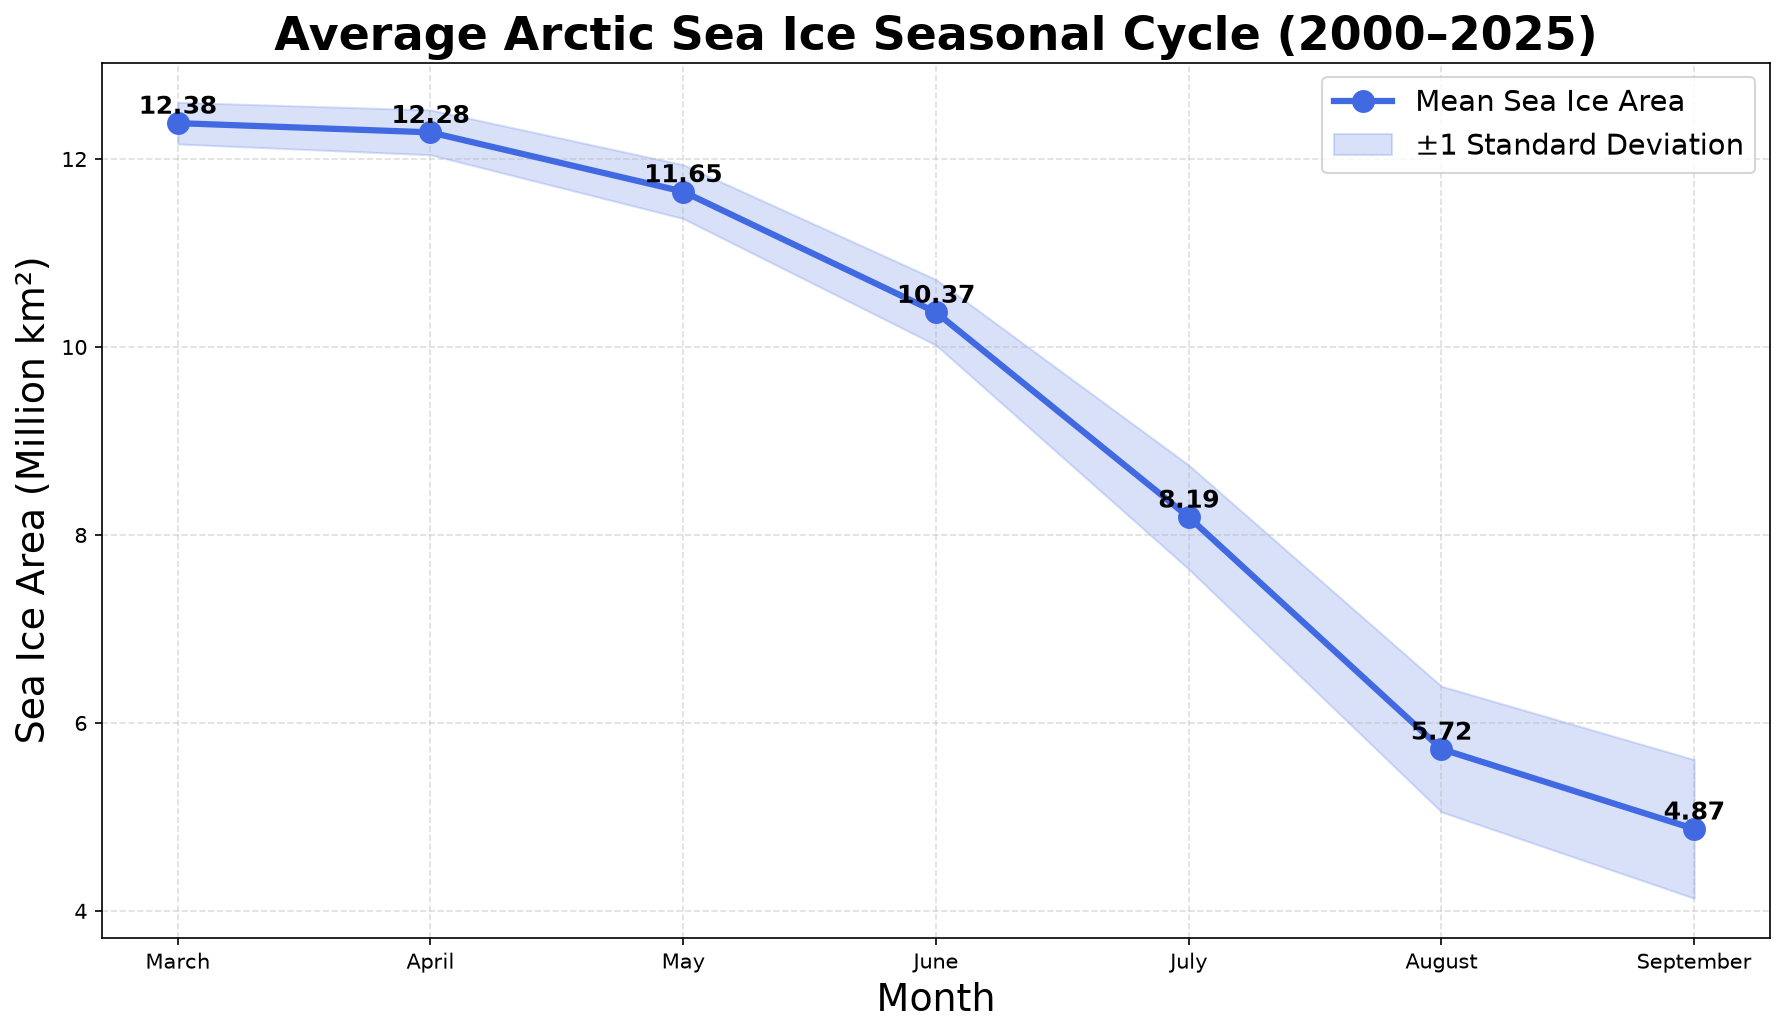

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------
# Read Master Dataset
# -------------------------------------------------------

df = pd.read_excel(
    r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_dataset\Sea_Ice_Master_Dataset.xlsx"
)

# Convert to Million km²
df["Sea Ice Area (Million km²)"] = df["Sea Ice Area (km²)"] / 1e6

months = [
    "March","April","May",
    "June","July","August","September"
]

means = []
stds = []

for month in months:

    values = df.loc[
        df["Month"] == month,
        "Sea Ice Area (Million km²)"
    ]

    means.append(values.mean())
    stds.append(values.std())

means = np.array(means)
stds = np.array(stds)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

plt.figure(figsize=(12,7))

plt.plot(
    months,
    means,
    color="royalblue",
    marker="o",
    markersize=10,
    linewidth=3,
    label="Mean Sea Ice Area"
)

plt.fill_between(
    months,
    means-stds,
    means+stds,
    color="royalblue",
    alpha=0.20,
    label="±1 Standard Deviation"
)

# Mean value labels
for x, y in zip(months, means):

    plt.text(
        x,
        y+0.10,
        f"{y:.2f}",
        fontsize=12,
        fontweight="bold",
        ha="center"
    )

plt.title(
    "Average Arctic Sea Ice Seasonal Cycle (2000–2025)",
    fontsize=22,
    fontweight="bold"
)

plt.xlabel(
    "Month",
    fontsize=18
)

plt.ylabel(
    "Sea Ice Area (Million km²)",
    fontsize=18
)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(fontsize=14)

plt.tight_layout()

plt.savefig(
    r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Average_Arctic_Sea_Ice_Seasonal_Cycle.png",
    dpi=600
)

plt.show()

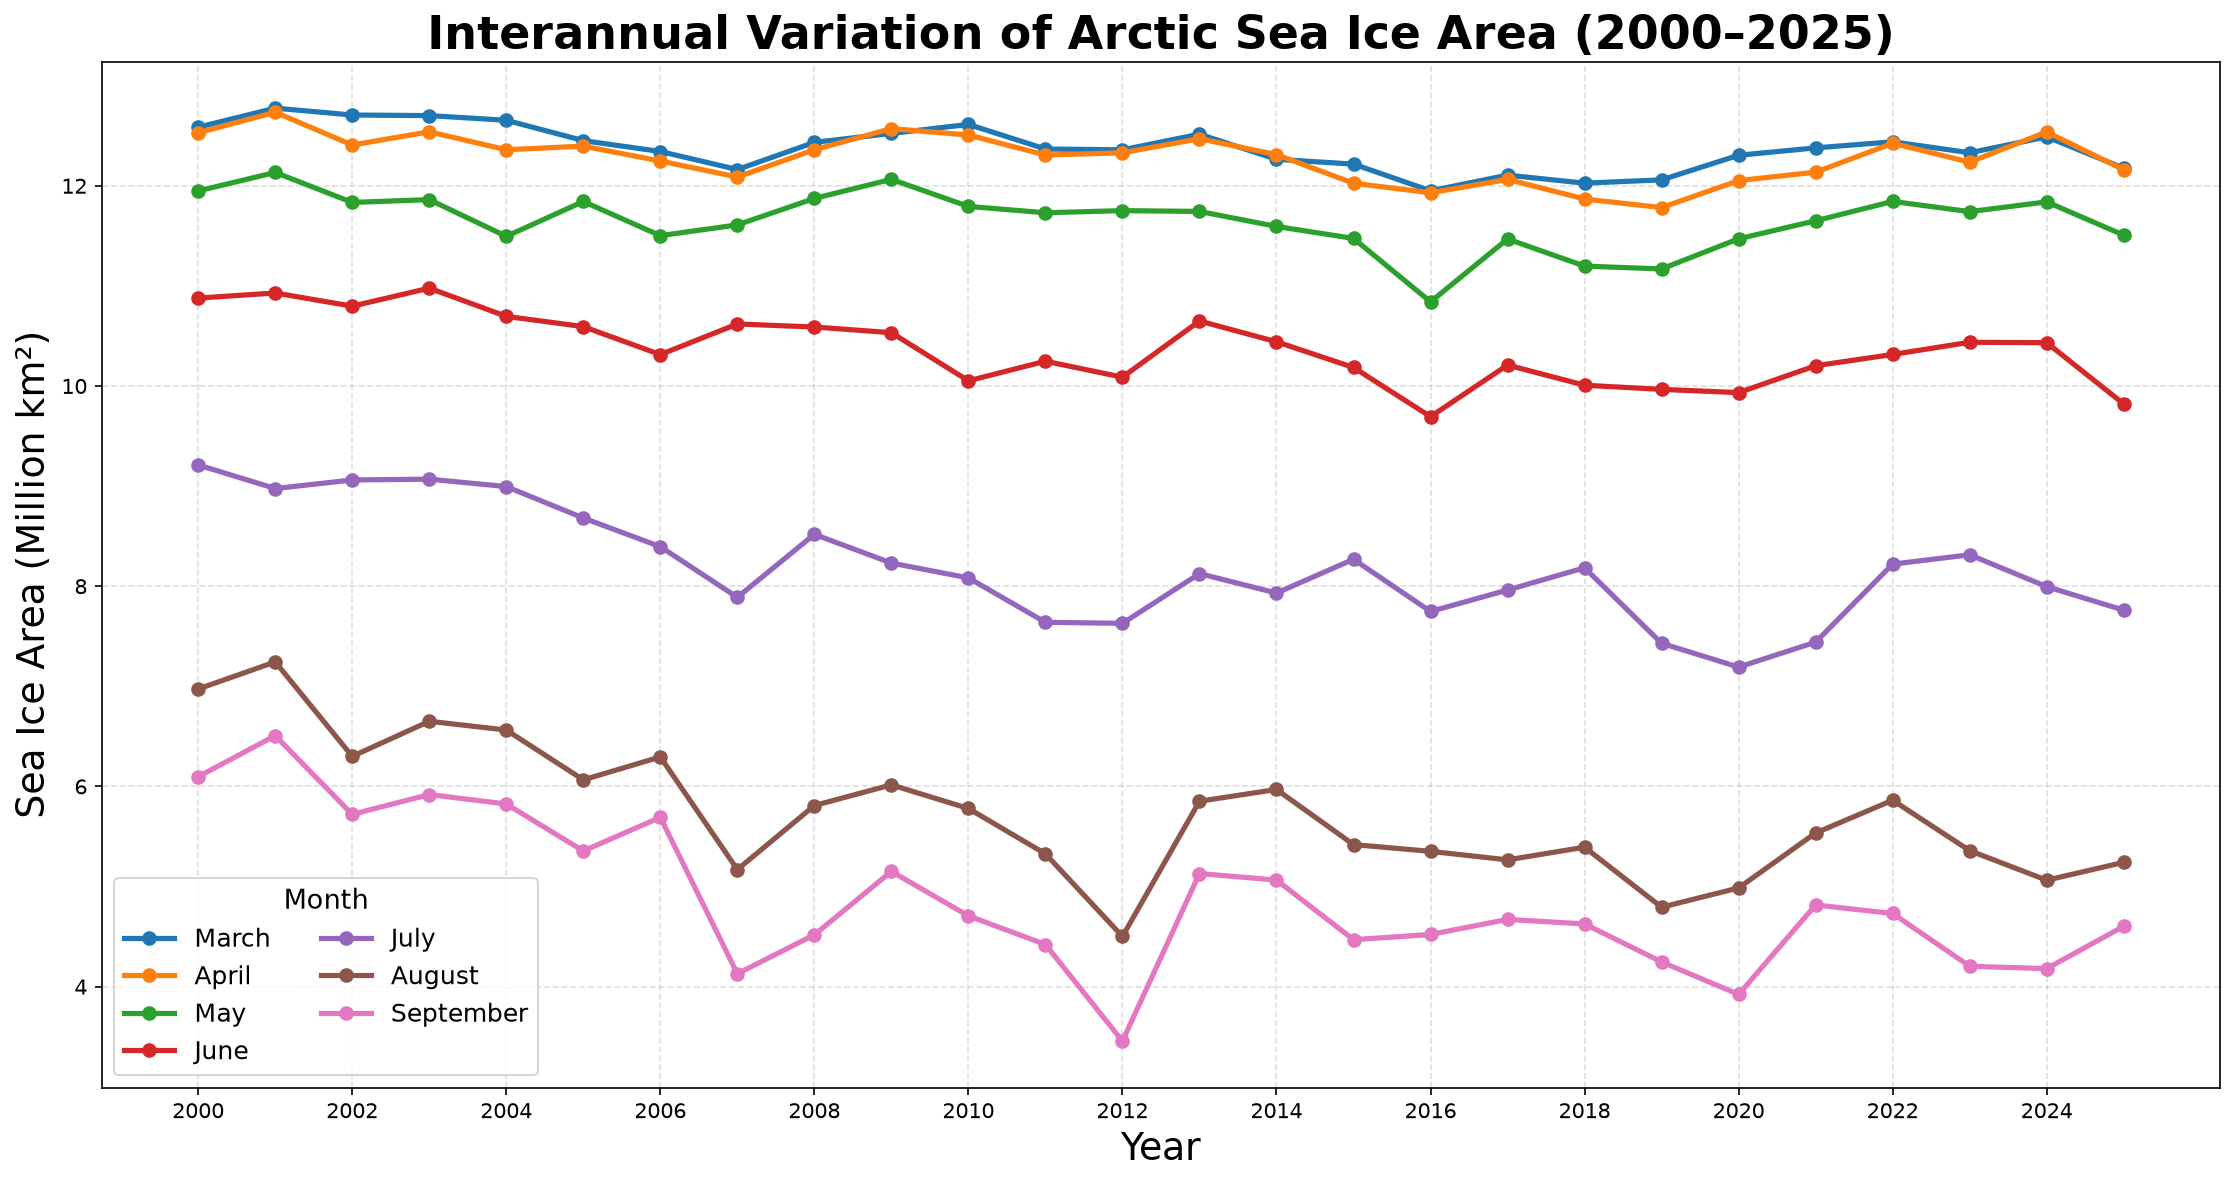

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Read Master Dataset
# ----------------------------------------------------------

file = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_dataset\Sea_Ice_Master_Dataset.xlsx"

df = pd.read_excel(file)

# ----------------------------------------------------------
# Convert km² to Million km²
# ----------------------------------------------------------

df["Sea Ice Area (Million km²)"] = df["Sea Ice Area (km²)"] / 1e6

# ----------------------------------------------------------
# Months
# ----------------------------------------------------------

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

# ----------------------------------------------------------
# Figure
# ----------------------------------------------------------

plt.figure(figsize=(15,8))

# ----------------------------------------------------------
# Plot each month
# ----------------------------------------------------------

for month in months:

    temp = df[df["Month"] == month]

    plt.plot(
        temp["Year"],
        temp["Sea Ice Area (Million km²)"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=month
    )

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

plt.title(
    "Interannual Variation of Arctic Sea Ice Area (2000–2025)",
    fontsize=22,
    fontweight="bold"
)

plt.xlabel(
    "Year",
    fontsize=18
)

plt.ylabel(
    "Sea Ice Area (Million km²)",
    fontsize=18
)

plt.xticks(range(2000,2026,2))

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Month",
    fontsize=12,
    title_fontsize=13,
    ncol=2
)

plt.tight_layout()

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

plt.savefig(
    r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Interannual_Sea_Ice_Area.png",
    dpi=600
)

plt.show()

In [ ]:
# import cv2
# import os
# from glob import glob

# # ==========================================================
# # INPUT & OUTPUT
# # ==========================================================

# IMAGE_FOLDER = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Yearly_Mean_PNG"

# OUTPUT_VIDEO = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Videos\Yearly_Sea_Ice_Graph.mp4"

# FPS = 2        # 2 frames per second (each graph visible for 0.5 sec)

# # ==========================================================
# # READ IMAGES
# # ==========================================================

# images = sorted(glob(os.path.join(IMAGE_FOLDER, "*.png")))

# print("Total Images :", len(images))

# if len(images) == 0:
#     raise FileNotFoundError("No PNG images found!")

# # ==========================================================
# # FIRST IMAGE
# # ==========================================================

# frame = cv2.imread(images[0])

# height, width = frame.shape[:2]

# print("Video Size :", width, "x", height)

# # ==========================================================
# # CREATE VIDEO
# # ==========================================================

# fourcc = cv2.VideoWriter_fourcc(*"mp4v")

# video = cv2.VideoWriter(
#     OUTPUT_VIDEO,
#     fourcc,
#     FPS,
#     (width, height)
# )

# # ==========================================================
# # ADD FRAMES
# # ==========================================================

# for img in images:

#     frame = cv2.imread(img)

#     # Safety: resize if any image has a different size
#     frame = cv2.resize(frame, (width, height))

#     # Show each year for 1 second (FPS=2 → write frame twice)
#     for _ in range(2):
#         video.write(frame)

#     print("Added :", os.path.basename(img))

# # ==========================================================
# # FINISH
# # ==========================================================

# video.release()

# print("\n======================================")
# print("Video Created Successfully!")
# print(OUTPUT_VIDEO)

Total Images : 26
Video Size : 4672 x 5103
Added : Year_2000.png
Added : Year_2001.png
Added : Year_2002.png
Added : Year_2003.png
Added : Year_2004.png
Added : Year_2005.png
Added : Year_2006.png
Added : Year_2007.png
Added : Year_2008.png
Added : Year_2009.png
Added : Year_2010.png
Added : Year_2011.png
Added : Year_2012.png
Added : Year_2013.png
Added : Year_2014.png
Added : Year_2015.png
Added : Year_2016.png
Added : Year_2017.png
Added : Year_2018.png
Added : Year_2019.png
Added : Year_2020.png
Added : Year_2021.png
Added : Year_2022.png
Added : Year_2023.png
Added : Year_2024.png
Added : Year_2025.png

Video Created Successfully!
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\Videos\Yearly_Sea_Ice_Graph.mp4


NameError: name 'heatmap_data' is not defined

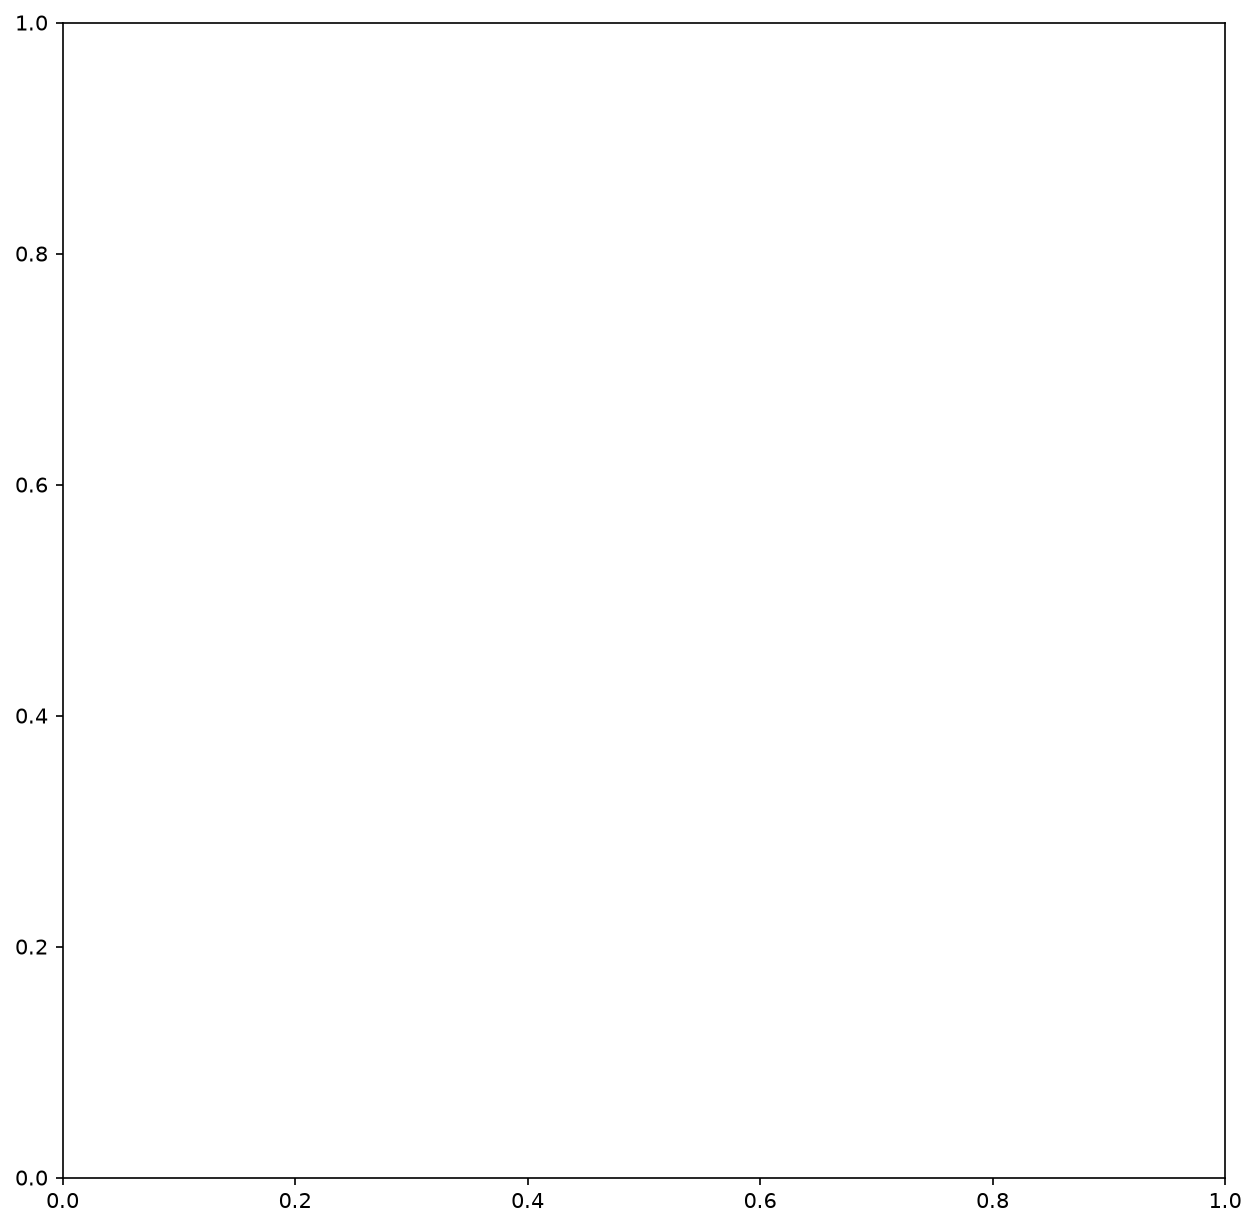

In [22]:
# ----------------------------------------------------------
# Heatmap
# ----------------------------------------------------------

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10,10))

im = ax.imshow(
    heatmap_data,
    cmap="Blues",
    aspect="auto"
)

# ----------------------------------------------------------
# Color Bar (Million km²)
# ----------------------------------------------------------

cbar = plt.colorbar(im)

# Convert km² → Million km²
ticks = cbar.get_ticks()

cbar.set_ticks(ticks)

cbar.set_ticklabels([f"{tick/1e6:.0f}" for tick in ticks])

cbar.set_label(
    "Sea Ice Area (Million km²)",
    fontsize=15
)

# Remove scientific notation (1e7)
cbar.ax.yaxis.offsetText.set_visible(False)

# ----------------------------------------------------------
# Axis Labels
# ----------------------------------------------------------

ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, fontsize=13)

ax.set_yticks(range(len(years)))
ax.set_yticklabels(years, fontsize=11)

plt.xlabel(
    "Month",
    fontsize=16
)

plt.ylabel(
    "Year",
    fontsize=16
)

plt.title(
    "Arctic Sea Ice Area (60°N–90°N)\n2000–2025",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()